# Task 2: Nonlinear models on the data — the Polynomial model

## Run Task 1

Comment unnecessary cells in task1.ipynb

In [ ]:
%run data_preparation.py

/home/pawluk/nova/ml/assignment-1/NOVA_ML_Project1/data_preparation.py:53: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _df = _df.groupby("traj_id", group_keys=False).apply(mark)


## Task 2.1 Development

In [14]:
from math import comb
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline


def validate_poly_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    regressor=None,
    degrees=range(1, 15),
    max_features=None,
):
    if regressor is None:
        # No regularization
        regressor = LinearRegression()

    best_rmse = np.inf
    best_model = None
    num_input_features = X_train.shape[1]

    for d in degrees:
        expected_num_poly_features = comb(num_input_features + d, d)

        # Check if we exceed max_features limit
        if max_features is not None and expected_num_poly_features > max_features:
            # print(f"degree={d:2d} -> poly features: {expected_num_poly_features:,} | SKIPPED (exceeds max_features={max_features:,})")
            continue

        model = make_pipeline(
                    PolynomialFeatures(degree=d),
                    StandardScaler(),
                    regressor) # Clone this one?
        
        model.fit(X_train, y_train)

        num_poly_features = model[0].n_output_features_
        y_pred = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))

        # OUTPUT COMMENTS
        # print(f"degree ={d:2d} ->\n\tnumber of polynomial features: {num_poly_features:,} (expected: {expected_num_poly_features:,}) | RMSE={rmse:.6f}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model
            best_degree = d
    

    return best_model, best_rmse, best_degree

### Validate on df_tiny
(data prepared earlier)

In [15]:
best_model, best_rmse, best_degree = validate_poly_regression(
    X_train, y_train, X_val, y_val,
    regressor=None,              # default LinearRegression (no regularization)
    degrees=range(1, 5),         # start with lower degrees for speed; expand later
    max_features=None            # set to an int (e.g., 2000) if degrees get too large
)
print("\n\nBest validation RMSE:", best_rmse, "for the degree =", best_model[0].degree)

n_feats_best = best_model[0].n_output_features_
print("Best model polynomial features (n_output_features_):", n_feats_best)



Best validation RMSE: 1.4006271610514553 for the degree = 1
Best model polynomial features (n_output_features_): 8


Validate with Ridge regression

In [ ]:
best_model, best_rmse, best_degree = validate_poly_regression(
        X_train, y_train, X_val, y_val,
        regressor=RidgeCV(alphas=[100]),
        degrees=range(1, 5),
        max_features=None
    )
print("\n\nBest validation RMSE:", best_rmse, "for the degree =", best_model[0].degree)

n_feats_best = best_model[0].n_output_features_
print("Best model polynomial features (n_output_features_):", n_feats_best)

chosen_alpha = best_model[2].alpha_
print(f"Chosen alpha value by RidgeCV: {chosen_alpha}")

# For some reason after running RidgeCV again when iterating, it changes in all instances of models with it.
# so we need to run it again with best degree for now.
# To be fixed.
best_model, best_rmse, best_degree = validate_poly_regression(
        X_train, y_train, X_val, y_val,
        regressor=RidgeCV(alphas=[100]),              # default LinearRegression (no regularization)
        degrees=[best_model[0].degree],        # start with lower degrees for speed; expand later
        max_features=None            # set to an int (e.g., 2000) if degrees get too large
    )



Best validation RMSE: 1.3768324576832647 for the degree = 3
Best model polynomial features (n_output_features_): 120
Chosen alpha value by RidgeCV: 100


In [17]:
print(best_model[0].n_output_features_)

120


### Look for best Ridge alpha for validation data

In [18]:
best_best_rmse = np.inf
best_i = None
for i in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 10000.0]:
    best_model, best_rmse, best_degree = validate_poly_regression(
        X_train, y_train, X_val, y_val,
        regressor=RidgeCV(alphas=[i]),              # default LinearRegression (no regularization)
        degrees=range(1, 5),         # start with lower degrees for speed; expand later
        max_features=None            # set to an int (e.g., 2000) if degrees get too large
    )
    best_degree = best_model[0].degree
    print("\n\nBest validation RMSE:", best_rmse, "for the degree =", best_model[0].degree)

    n_feats_best = best_model[0].n_output_features_
    print("Best model polynomial features (n_output_features_):", n_feats_best)

    chosen_alpha = best_model[2].alpha_
    print(f"\n\nChosen alpha value by RidgeCV: {chosen_alpha}")

    if best_rmse < best_best_rmse:
        best_best_rmse = best_rmse
        best_i = i

print("\n\nbest alpha:", best_i, "| degree:", best_degree, "| rmse:", best_best_rmse)



Best validation RMSE: 1.4006271567859832 for the degree = 1
Best model polynomial features (n_output_features_): 8


Chosen alpha value by RidgeCV: 0.001


Best validation RMSE: 1.4006271229248453 for the degree = 1
Best model polynomial features (n_output_features_): 8


Chosen alpha value by RidgeCV: 0.01


Best validation RMSE: 1.4006267801143526 for the degree = 1
Best model polynomial features (n_output_features_): 8


Chosen alpha value by RidgeCV: 0.1


Best validation RMSE: 1.4006233521639375 for the degree = 1
Best model polynomial features (n_output_features_): 8


Chosen alpha value by RidgeCV: 1.0


Best validation RMSE: 1.4005891160578356 for the degree = 1
Best model polynomial features (n_output_features_): 8


Chosen alpha value by RidgeCV: 10.0


Best validation RMSE: 1.3768324576832647 for the degree = 3
Best model polynomial features (n_output_features_): 120


Chosen alpha value by RidgeCV: 100.0


Best validation RMSE: 1.3622883866991096 for the degree = 3
Best m

### Compare other regularization methods

### Polynomial degree distribution analysis

Run your function ten times and examine the distribution of the selected polynomial degrees.

Run 1: Best validation RMSE: 2.232756 for degree = 4
Run 2: Best validation RMSE: 0.998647 for degree = 1
Run 3: Best validation RMSE: 1.314468 for degree = 1
Run 4: Best validation RMSE: 0.920145 for degree = 1
Run 5: Best validation RMSE: 2.193033 for degree = 2
Run 6: Best validation RMSE: 1.402839 for degree = 4
Run 7: Best validation RMSE: 2.186105 for degree = 4
Run 8: Best validation RMSE: 1.235568 for degree = 4
Run 9: Best validation RMSE: 1.078062 for degree = 4
Run 10: Best validation RMSE: 1.413916 for degree = 3


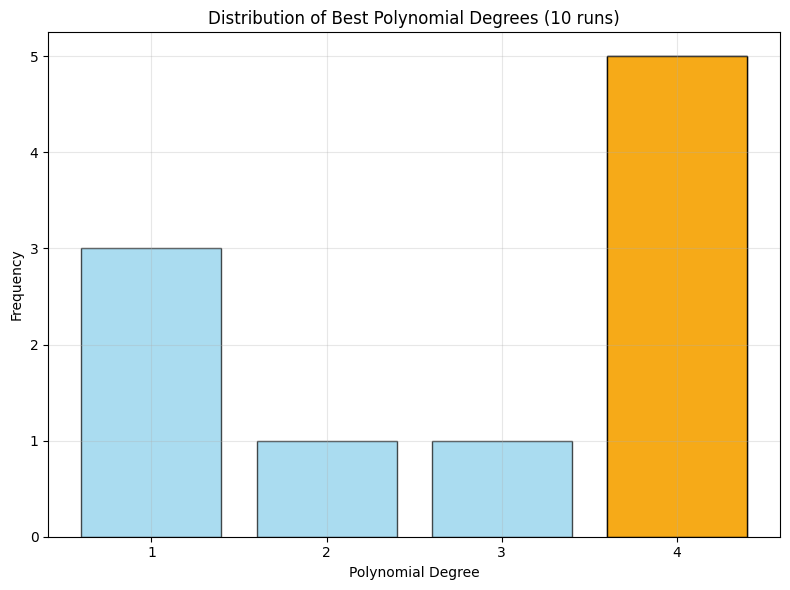


Degree distribution: {1: 3, 2: 1, 3: 1, 4: 5}
Most frequent degree: 4 (appeared 5 times)
Global variable 'most_freq_degree' set to: 4


In [19]:
import matplotlib.pyplot as plt

degrees = []

for i in range(10):
    df_tiny = generate_df_subset(df_clean, 0.02, rng)
    split_df(df_tiny, rng, 0.75)

    X_train, y_train = prepare_data(df_tiny, "train")
    X_val, y_val = prepare_data(df_tiny, "val")

    best_model, best_rmse, best_degree = validate_poly_regression(
        X_train,
        y_train,
        X_val,
        y_val,
        regressor=None,
        degrees=range(1, 5),
        max_features=None,
    )
    
    degrees.append(best_degree)
    print(f"Run {i+1}: Best validation RMSE: {best_rmse:.6f} for degree = {best_degree}")

# Count degree frequencies manually
unique_degrees = sorted(set(degrees))
degree_counts = {}
for degree in unique_degrees:
    degree_counts[degree] = degrees.count(degree)

# Find most frequent degree
most_freq_degree = max(degree_counts, key=degree_counts.get)

# Create the plot
plt.figure(figsize=(8, 6))
counts = [degree_counts[d] for d in unique_degrees]

plt.bar(unique_degrees, counts, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Polynomial Degree')
plt.ylabel('Frequency')
plt.title('Distribution of Best Polynomial Degrees (10 runs)')
plt.xticks(unique_degrees)
plt.grid(True, alpha=0.3)

# Highlight most frequent degree
max_count = max(counts)
for degree, count in degree_counts.items():
    if count == max_count:
        plt.bar(degree, count, alpha=0.9, color='orange', edgecolor='black')

plt.tight_layout()
plt.show()

print(f"\nDegree distribution: {degree_counts}")
print(f"Most frequent degree: {most_freq_degree} (appeared {degree_counts[most_freq_degree]} times)")
print(f"Global variable 'most_freq_degree' set to: {most_freq_degree}")

# Task 2.2

Evaluate polynomial regression model against the linear regression baseline from Task 1.

### Train baseline linear model (from Task 1)

In [20]:
# Train linear regression model (baseline from Task 1)
linear_model = make_pipeline(StandardScaler(), LinearRegression())
linear_model.fit(X_train, y_train)

# Make predictions with linear model
y_pred_linear = linear_model.predict(X_val)

# Calculate RMSE for linear model
linear_rmse = np.sqrt(mean_squared_error(y_val, y_pred_linear))
print(f"Linear Regression - Validation RMSE: {linear_rmse:.6f}")

# Store for comparison
linear_model_trained = linear_model

Linear Regression - Validation RMSE: 1.528790


### Train polynomial model using most frequent degree

In [21]:
# Train polynomial regression model using the most frequent degree
print(f"Using polynomial degree: {most_freq_degree}")

poly_model = make_pipeline(
    PolynomialFeatures(degree=most_freq_degree),
    StandardScaler(),
    LinearRegression()
)
poly_model.fit(X_train, y_train)

# Make predictions with polynomial model
y_pred_poly = poly_model.predict(X_val)

# Calculate RMSE for polynomial model
poly_rmse = np.sqrt(mean_squared_error(y_val, y_pred_poly))
print(f"Polynomial Regression (degree {most_freq_degree}) - Validation RMSE: {poly_rmse:.6f}")

# Show improvement
improvement = ((linear_rmse - poly_rmse) / linear_rmse) * 100
print(f"RMSE improvement: {improvement:.2f}%")

Using polynomial degree: 4
Polynomial Regression (degree 4) - Validation RMSE: 1.423899
RMSE improvement: 6.86%


### Compare models with y vs ŷ plots

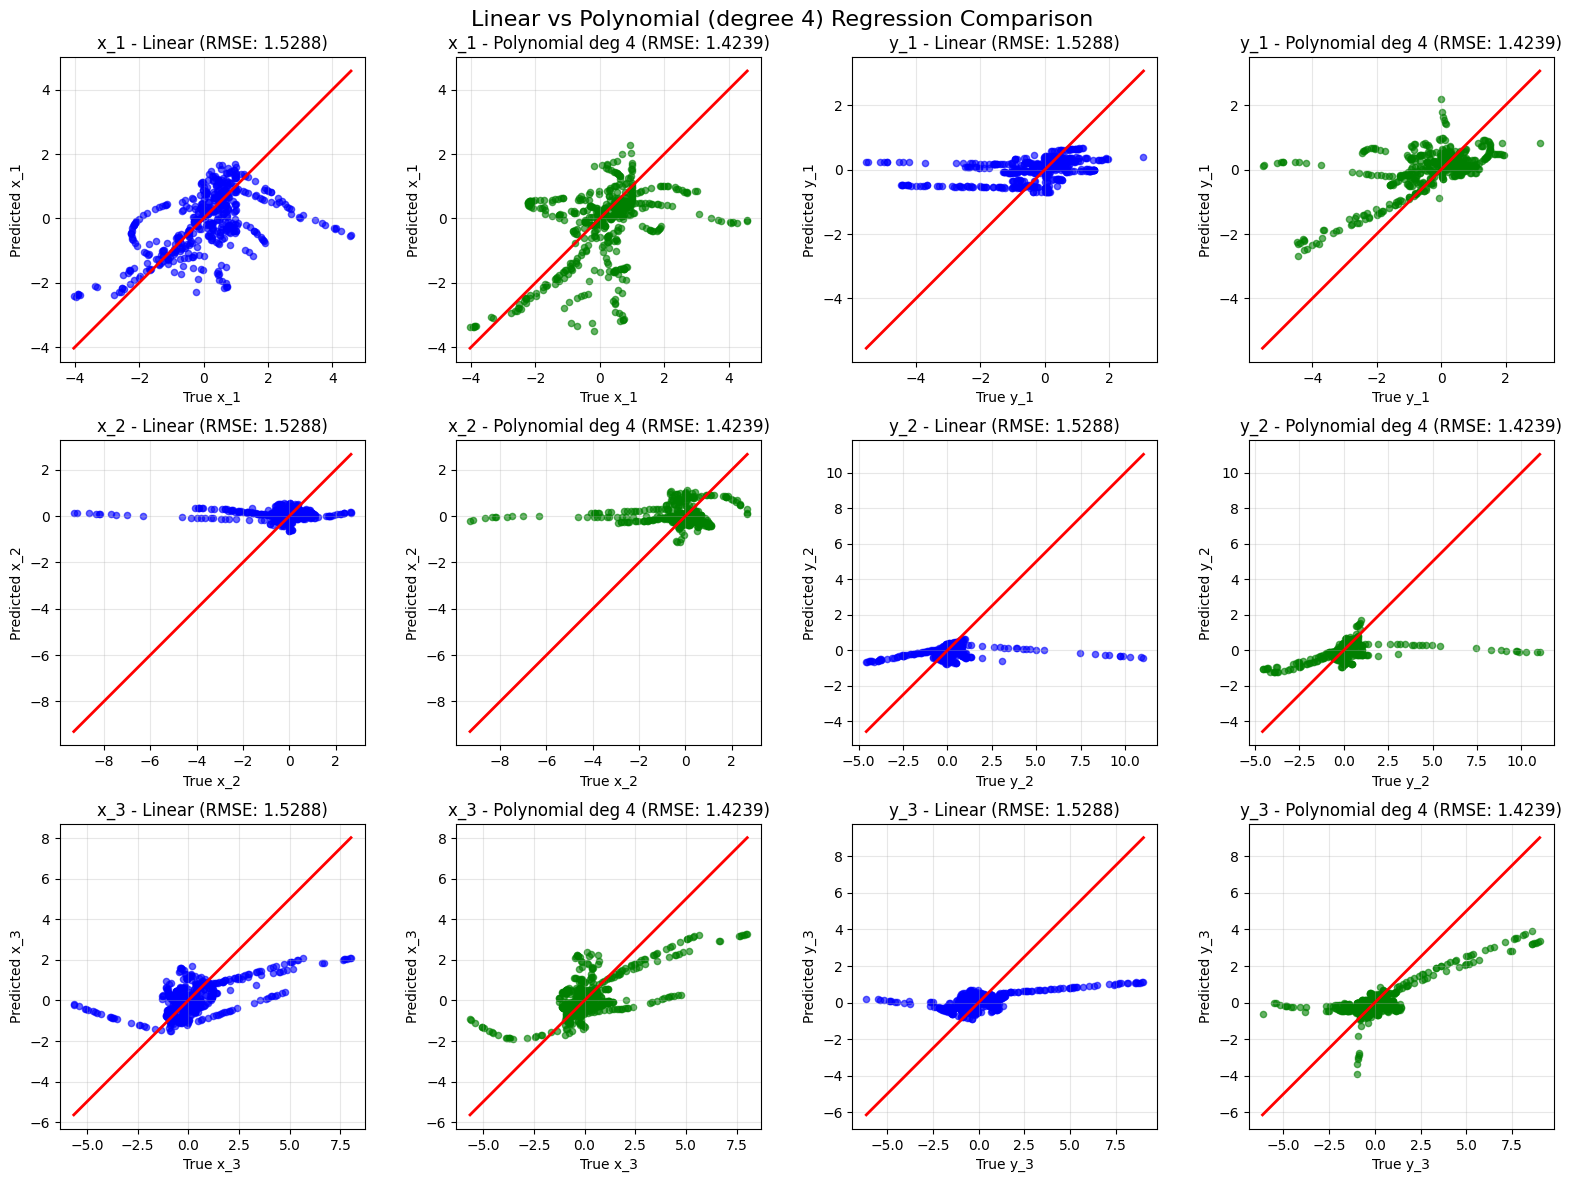

Saved: results/linear_vs_polynomial_comparison.png


In [22]:
def plot_comparison_y_yhat(y_test, y_pred_linear, y_pred_poly, linear_rmse, poly_rmse, degree):
    """Plot comparison of linear vs polynomial regression predictions"""
    labels = ['x_1', 'y_1', 'x_2', 'y_2', 'x_3', 'y_3']
    MAX = 500  # Maximum points to plot
    
    # Sample points if dataset is too large
    if len(y_test) > MAX:
        idx = np.random.choice(len(y_test), MAX, replace=False)
    else:
        idx = np.arange(len(y_test))
    
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    fig.suptitle(f'Linear vs Polynomial (degree {degree}) Regression Comparison', fontsize=16)
    
    for i in range(6):
        row = i // 2
        
        # Linear regression plot (left column)
        ax_linear = axes[row, i % 2 * 2]
        
        # min/max for diagonal line
        x0 = np.min(y_test[idx, i])
        x1 = np.max(y_test[idx, i])
        
        # Scatter plot: predicted vs actual for linear
        ax_linear.scatter(y_test[idx, i], y_pred_linear[idx, i], alpha=0.6, s=20, color='blue')
        ax_linear.plot([x0, x1], [x0, x1], color='red', linewidth=2, label='Perfect prediction')
        ax_linear.set_xlabel('True ' + labels[i])
        ax_linear.set_ylabel('Predicted ' + labels[i])
        ax_linear.set_title(f'{labels[i]} - Linear (RMSE: {linear_rmse:.4f})')
        ax_linear.grid(True, alpha=0.3)
        ax_linear.set_aspect('equal', adjustable='box')
        
        # Polynomial regression plot (right column)
        ax_poly = axes[row, i % 2 * 2 + 1]
        
        # Scatter plot: predicted vs actual for polynomial
        ax_poly.scatter(y_test[idx, i], y_pred_poly[idx, i], alpha=0.6, s=20, color='green')
        ax_poly.plot([x0, x1], [x0, x1], color='red', linewidth=2, label='Perfect prediction')
        ax_poly.set_xlabel('True ' + labels[i])
        ax_poly.set_ylabel('Predicted ' + labels[i])
        ax_poly.set_title(f'{labels[i]} - Polynomial deg {degree} (RMSE: {poly_rmse:.4f})')
        ax_poly.grid(True, alpha=0.3)
        ax_poly.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.savefig(f'results/linear_vs_polynomial_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Saved: results/linear_vs_polynomial_comparison.png")

# Create the comparison plot
plot_comparison_y_yhat(y_val, y_pred_linear, y_pred_poly, linear_rmse, poly_rmse, most_freq_degree)

## Create submission

In [23]:
submission_model, _, _ = validate_poly_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    RidgeCV(alphas=[10000.0]),
    # None,
    degrees = [3]
)

In [ ]:
# y_pred = submission_model.predict(X_test)

# pred_df = export_predictions_to_csv(y_pred, RESULTS_DIR / "polynomial-submission.csv")

Predictions saved to: results/polynomial-submission.csv
Shape: (1041621, 7)
First few rows:
   Id       x_1       y_1       x_2       y_2       x_3       y_3
0   0  0.783297 -0.134749 -0.358349  0.365640 -0.424948 -0.230891
1   1  0.776179 -0.136784 -0.357661  0.361679 -0.418518 -0.224895
2   2  0.769062 -0.138811 -0.356970  0.357722 -0.412092 -0.218911
3   3  0.761944 -0.140827 -0.356274  0.353768 -0.405670 -0.212940
4   4  0.754826 -0.142835 -0.355575  0.349816 -0.399251 -0.206981
